In [1]:
!pip install -U bitsandbytes
#Import
from diffusers import UNet2DConditionModel, StableDiffusionPipeline
from transformers import BitsAndBytesConfig, CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model
import torch
from peft import LoraConfig, get_peft_model, PeftModel
import pandas as pd


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 38.9 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:
# Each group has a label and 3 prompt variants
attribute_groups = {
    'neutral': [
        'a high-quality studio portrait of sks_person, neutral expression, plain grey background, soft even lighting',
        'a photo of sks_person, expressionless face, looking at camera, plain background',
        'a realistic headshot of sks_person, calm neutral expression, studio lighting',
    ],
    'smiling': [
        'a high-quality portrait of sks_person, big natural smile, teeth visible, warm soft lighting',
        'a photo of sks_person, laughing, happy expression, candid style',
        'a realistic portrait of sks_person, wide smile, joyful expression, soft background',
    ],
    'glasses': [
        'a realistic portrait of sks_person, wearing clear-framed glasses, neutral expression, plain background',
        'a photo of sks_person, wearing prescription glasses, looking at camera, studio lighting',
        'a high-quality headshot of sks_person, with glasses, soft even lighting, grey background',
    ],
    'older': [
        'a realistic portrait of sks_person aged 60, wrinkles, grey hair, neutral expression, studio lighting',
        'a photo of sks_person as an elderly person, aged face, soft lighting',
        'a high-quality portrait of sks_person, 65 years old, realistic skin aging, plain background',
    ],
    'outdoor': [
        'a realistic outdoor portrait of sks_person, natural daylight, city street background, shallow depth of field',
        'a photo of sks_person standing outdoors, sunny day, blurred greenery background',
        'a candid outdoor photo of sks_person, natural light, urban background, bokeh',
    ],
}

IMAGES_PER_PROMPT = 10
INFERENCE_STEPS   = 30

print('Attribute groups defined:')
for k, v in attribute_groups.items():
    print(f'  {k}: {len(v)} prompts × {IMAGES_PER_PROMPT} images = {len(v)*IMAGES_PER_PROMPT} total')

Attribute groups defined:
  neutral: 3 prompts × 10 images = 30 total
  smiling: 3 prompts × 10 images = 30 total
  glasses: 3 prompts × 10 images = 30 total
  older: 3 prompts × 10 images = 30 total
  outdoor: 3 prompts × 10 images = 30 total


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
output_dir="/content/drive/MyDrive/QLoRA/Person_861/lora_output_861_qlora"
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
)

# Load 4-bit UNet base
unet = UNet2DConditionModel.from_pretrained(
    'runwayml/stable-diffusion-v1-5',
    subfolder='unet',
    quantization_config=quant_config,
    device_map='auto',
    torch_dtype=torch.float16,
)

# Load the PEFT LoRA adapters saved during training
unet = PeftModel.from_pretrained(unet,output_dir)

# Assemble inference pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    'runwayml/stable-diffusion-v1-5',
    unet=unet,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
)
pipe.to('cuda')

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Expected types for unet: (<class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>,), got <class 'peft.peft_model.PeftModel'>.


StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.37.1",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": false,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [7]:
import os
from tqdm import tqdm
target_person=861
attr_root = f'/content/attribute_control_{target_person}'
os.makedirs(attr_root, exist_ok=True)

for attr_name, prompts in attribute_groups.items():
    attr_dir = os.path.join(attr_root, attr_name)
    os.makedirs(attr_dir, exist_ok=True)

    img_idx = 0
    print(f'\nGenerating: {attr_name}')
    for prompt in prompts:
        for _ in tqdm(range(IMAGES_PER_PROMPT), desc=f'  prompt: {prompt[:50]}...'):
            image = pipe(
                prompt,
                num_inference_steps=INFERENCE_STEPS,
                guidance_scale=7.5,
            ).images[0]
            image.save(os.path.join(attr_dir, f'img_{img_idx}.png'))
            img_idx += 1

    print(f'  Saved {img_idx} images → {attr_dir}')

print('\nAll attribute groups generated.')


Generating: neutral


  prompt: a high-quality studio portrait of sks_person, neut...:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  prompt: a high-quality studio portrait of sks_person, neut...:  10%|█         | 1/10 [00:05<00:53,  5.95s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  prompt: a candid outdoor photo of sks_person, natural ligh...:  90%|█████████ | 9/10 [00:37<00:04,  4.22s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

  prompt: a candid outdoor photo of sks_person, natural ligh...: 100%|██████████| 10/10 [00:42<00:00,  4.21s/it]

  Saved 30 images → /content/attribute_control_861/outdoor

All attribute groups generated.


In [8]:
import zipfile
zip_path     = '/content/drive/MyDrive/CelebAMask-HQ.zip'
extract_path = '/content/celeba_data/'

if not os.path.exists(extract_path):
    print('Extracting to local storage...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print('Extraction complete.')
else:
    print('Dataset already extracted — skipping.')

Extracting to local storage...
Extraction complete.


In [9]:
# Load the HQ↔original bridge mapping
mapping_df = pd.read_csv(
    '/content/celeba_data/CelebAMask-HQ/CelebA-HQ-to-CelebA-mapping.txt',
    sep=r'\s+', header=0
)

# Load original identity labels
identity_df = pd.read_csv(
    '/content/drive/MyDrive/identity_CelebA.txt',
    sep=r'\s+', header=None, names=['orig_file', 'person_id']
)

# Merge and build HQ filename column
merged_df = pd.merge(mapping_df, identity_df, on='orig_file')
merged_df['hq_filename'] = merged_df['idx'].apply(lambda x: f'{x}.jpg')
final_mapping = merged_df[['hq_filename', 'person_id']]

print(final_mapping.head())

  hq_filename  person_id
0       0.jpg       7423
1       1.jpg       7319
2       2.jpg       6632
3       3.jpg       3338
4       4.jpg       9178


In [10]:
# Count HQ images per person and filter for >= 5
id_counts  = final_mapping['person_id'].value_counts()
candidates = id_counts[id_counts >= 5].index.tolist()
print(f'Total candidates with >=5 images: {len(candidates)}')

# Pick person 861
target_person = candidates[0]
print(f'Using: {target_person}')

Total candidates with >=5 images: 2398
Using: 861


In [11]:
import shutil
base_img_path = '/content/celeba_data/CelebAMask-HQ/CelebA-HQ-img/'
path_1shot    = f'/content/train_{target_person}_1shot'

os.makedirs(path_1shot, exist_ok=True)

# Get all HQ image filenames for this person
person_images = final_mapping[
    final_mapping['person_id'] == target_person
]['hq_filename'].tolist()

# Copy only 1 image for 1-shot
dst = os.path.join(path_1shot, 'img_0.jpg')
shutil.copy(os.path.join(base_img_path, person_images[0]), dst)

print(f'Folder contents : {os.listdir(path_1shot)}')
print(f'Source image    : {person_images[0]}')
print(f'Copied to       : {dst}')

Folder contents : ['img_0.jpg']
Source image    : 183.jpg
Copied to       : /content/train_861_1shot/img_0.jpg


In [12]:
!pip install deepface
import numpy as np
from deepface import DeepFace
from tqdm import tqdm

def get_embedding(img_path):
    try:
        result = DeepFace.represent(img_path, model_name='ArcFace', enforce_detection=False)
        return np.array(result[0]['embedding'])
    except:
        return None

def cosine_sim(a, b):
    a = a / (np.linalg.norm(a) + 1e-8)
    b = b / (np.linalg.norm(b) + 1e-8)
    return float(np.dot(a, b))

# Reference embedding from the 1-shot training image
ref_files = [f for f in os.listdir(path_1shot) if f.lower().endswith(('.jpg', '.png'))]
ref_emb   = get_embedding(os.path.join(path_1shot, ref_files[0]))
print(f'Reference image: {ref_files[0]}')

# Compute FRS for each group
frs_results = {}

for attr_name in attribute_groups.keys():
    attr_dir = os.path.join(attr_root, attr_name)
    sims     = []

    for fn in tqdm(os.listdir(attr_dir), desc=f'FRS [{attr_name}]'):
        if fn.lower().endswith('.png'):
            emb = get_embedding(os.path.join(attr_dir, fn))
            if emb is not None:
                sims.append(cosine_sim(emb, ref_emb))

    frs_results[attr_name] = sims
    print(f'  {attr_name:10s} → mean={np.mean(sims):.4f}  std={np.std(sims):.4f}  n={len(sims)}')

print('\nFRS computation complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.7 MB/s eta 0:00:00
26-05-10 01:21:56 - Directory /root/.deepface has been created
26-05-10 01:21:56 - Directory /root/.deepface/weights has been created


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5


26-05-10 01:21:58 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


100%|██████████| 137M/137M [00:01<00:00, 96.4MB/s]


Reference image: img_0.jpg


...

  glasses    → mean=0.2883  std=0.0649  n=30


FRS [older]: 100%|██████████| 30/30 [00:06<00:00,  4.83it/s]


  older      → mean=0.3342  std=0.0581  n=30


FRS [outdoor]: 100%|██████████| 30/30 [00:06<00:00,  4.87it/s]

  outdoor    → mean=0.3066  std=0.0920  n=30

FRS computation complete.


In [13]:
import pandas as pd

rows = []
for attr_name, sims in frs_results.items():
    rows.append({
        'Attribute'  : attr_name,
        'N images'   : len(sims),
        'FRS mean'   : round(np.mean(sims), 4),
        'FRS std'    : round(np.std(sims),  4),
        'FRS min'    : round(np.min(sims),  4),
        'FRS max'    : round(np.max(sims),  4),
    })

df = pd.DataFrame(rows).set_index('Attribute')
print(df.to_string())

# Drop from neutral to each attribute
neutral_mean = df.loc['neutral', 'FRS mean']
print('\nFRS drop vs neutral:')
for attr in df.index:
    if attr != 'neutral':
        drop = neutral_mean - df.loc[attr, 'FRS mean']
        print(f'  neutral → {attr:10s}: Δ = {drop:+.4f}')

           N images  FRS mean  FRS std  FRS min  FRS max
Attribute                                               
neutral          30    0.4011   0.0678   0.2585   0.5913
smiling          30    0.2981   0.1821  -0.0204   0.5102
glasses          30    0.2883   0.0649   0.1514   0.4097
older            30    0.3342   0.0581   0.2043   0.4481
outdoor          30    0.3066   0.0920  -0.0188   0.4410

FRS drop vs neutral:
  neutral → smiling   : Δ = +0.1030
  neutral → glasses   : Δ = +0.1128
  neutral → older     : Δ = +0.0669
  neutral → outdoor   : Δ = +0.0945


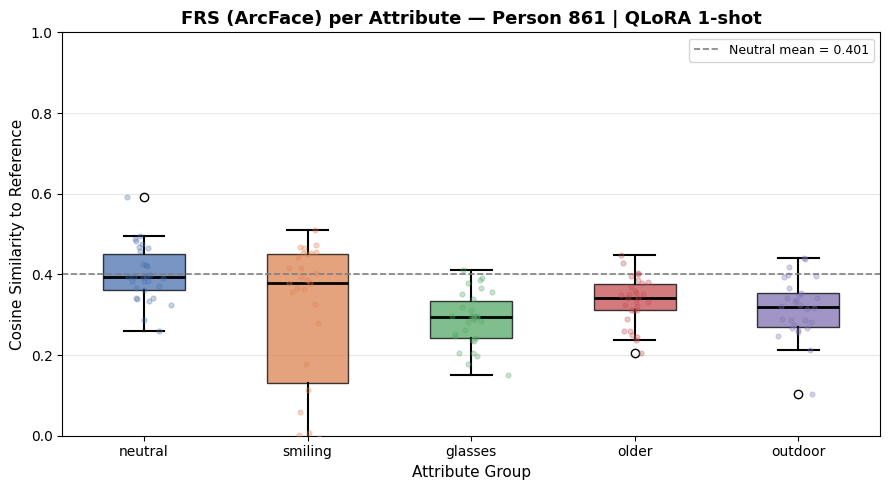

Boxplot saved to Drive.


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

labels = list(frs_results.keys())
data   = [frs_results[k] for k in labels]

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Overlay individual points
for i, (d, color) in enumerate(zip(data, colors), start=1):
    x = np.random.normal(i, 0.06, size=len(d))
    ax.scatter(x, d, alpha=0.3, s=12, color=color, zorder=3)

# Neutral mean reference line
ax.axhline(
    y=np.mean(frs_results['neutral']),
    color='grey', linestyle='--', linewidth=1.2,
    label=f"Neutral mean = {np.mean(frs_results['neutral']):.3f}"
)

ax.set_title(
    f'FRS (ArcFace) per Attribute — Person {target_person} | QLoRA 1-shot',
    fontsize=13, fontweight='bold'
)
ax.set_ylabel('Cosine Similarity to Reference', fontsize=11)
ax.set_xlabel('Attribute Group', fontsize=11)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/QLoRA/attribute_frs_boxplot_{target_person}.png', dpi=150)
plt.show()
print('Boxplot saved to Drive.')

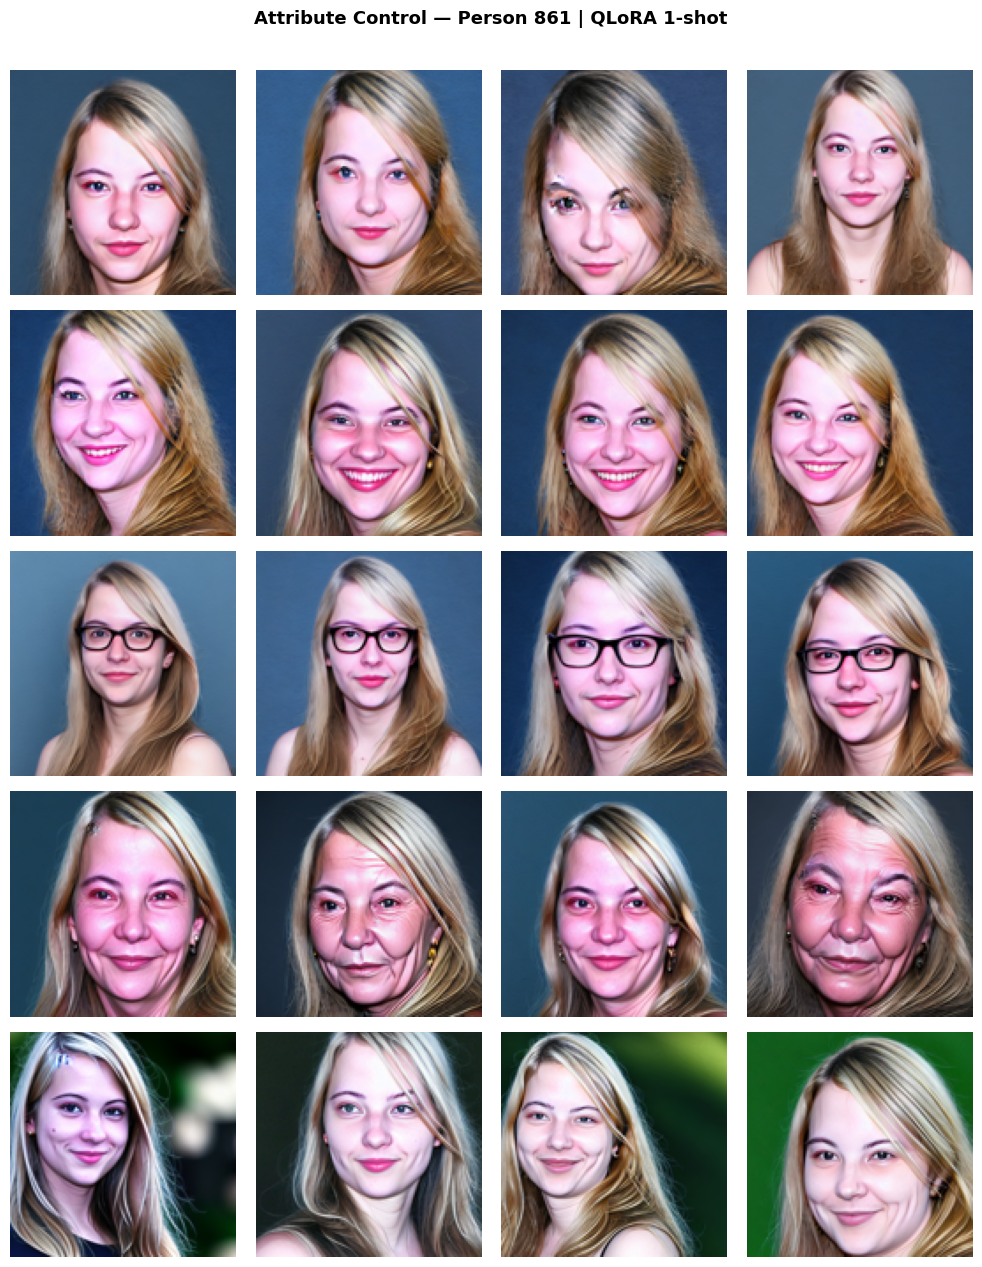

Visual grid saved to Drive.


In [15]:
import random
from PIL import Image
import matplotlib.pyplot as plt

SAMPLES_PER_GROUP = 4
n_groups = len(attribute_groups)

fig, axes = plt.subplots(
    n_groups, SAMPLES_PER_GROUP,
    figsize=(SAMPLES_PER_GROUP * 2.5, n_groups * 2.5)
)

for row, attr_name in enumerate(attribute_groups.keys()):
    attr_dir   = os.path.join(attr_root, attr_name)
    all_images = [f for f in os.listdir(attr_dir) if f.endswith('.png')]
    sampled    = random.sample(all_images, min(SAMPLES_PER_GROUP, len(all_images)))

    for col, fn in enumerate(sampled):
        img = Image.open(os.path.join(attr_dir, fn)).resize((128, 128))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            frs_mean = np.mean(frs_results[attr_name])
            axes[row][col].set_ylabel(
                f'{attr_name}\nFRS={frs_mean:.3f}',
                fontsize=9, rotation=0, labelpad=60, va='center'
            )

plt.suptitle(
    f'Attribute Control — Person {target_person} | QLoRA 1-shot',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    f'/content/drive/MyDrive/QLoRA/attribute_grid_{target_person}.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Visual grid saved to Drive.')

In [16]:
import shutil

drive_attr_dir = f'/content/drive/MyDrive/QLoRA/Person_{target_person}/attribute_control'
os.makedirs(drive_attr_dir, exist_ok=True)

# Copy all attribute images
shutil.copytree(attr_root, os.path.join(drive_attr_dir, 'images'), dirs_exist_ok=True)

# Save FRS table as CSV
df.to_csv(os.path.join(drive_attr_dir, f'frs_per_attribute_{target_person}.csv'))

print(f'All results saved to {drive_attr_dir}')
print(df)

All results saved to /content/drive/MyDrive/QLoRA/Person_861/attribute_control
           N images  FRS mean  FRS std  FRS min  FRS max
Attribute                                               
neutral          30    0.4011   0.0678   0.2585   0.5913
smiling          30    0.2981   0.1821  -0.0204   0.5102
glasses          30    0.2883   0.0649   0.1514   0.4097
older            30    0.3342   0.0581   0.2043   0.4481
outdoor          30    0.3066   0.0920  -0.0188   0.4410
